# Rheology of Newtonian & Non-Newtonian Materials

Apply the `RheologyPipeline` (from `rheology_pipeline_core.py`) to the five datasets in this folder and visualise the rheology of each sample **step-by-step**:

| # | Dataset       | Material family            | Expected behaviour                  |
|---|---------------|----------------------------|-------------------------------------|
| 1 | `silicone.csv`| Silicone oils (calibration)| Newtonian (single-RPM per cell)     |
| 2 | `PEG.csv`     | Poly-ethylene glycol       | Newtonian → mildly shear-thinning   |
| 3 | `sepineo.csv` | Sepineo (acrylate gel)     | Shear-thinning                      |
| 4 | `solagum.csv` | Solagum (polysaccharide)   | Strongly shear-thinning             |
| 5 | `carbopol.csv`| Carbopol 980 (yield-stress)| Shear-thinning (yield-pseudoplastic)|

The pipeline:
1. Fits each drag profile $D(h)=A/(h+h_c)+B$ to extract the amplitude $A$.
2. Converts $A \to \mu_\text{app}$ via the silicone calibration $A=k\,\mu^p$.
3. If multiple RPMs are present per cell, fits a power-law $A(\dot\gamma)=A_0\,\dot\gamma^{\,n-1}$ to classify the flow regime.

## Step 1 — Imports, paths & plotting style

In [40]:
import sys, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── Make the repo importable ─────────────────────────────────────────────────
REPO = Path(r"C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry")
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from rheology_pipeline_core import RheologyPipeline, fit_drag_profile

# ── Dataset paths ────────────────────────────────────────────────────────────
DATA_DIR  = REPO / "Rheology_Newtonian_Non_Newtonian_Material"
CALIB_CSV = REPO / "results" / "Auto-runs" / "height_normalized.csv"

SAMPLES = {
    "silicone": DATA_DIR / "silicone.csv",
    "PEG"     : DATA_DIR / "PEG.csv",
    "sepineo" : DATA_DIR / "sepineo.csv",
    "solagum" : DATA_DIR / "solagum.csv",
    "carbopol": DATA_DIR / "carbopol.csv",
}

# ── Google plotting style ────────────────────────────────────────────────────
mpl.rcParams["font.family"] = "Arial"
GOOGLE_COLORS = ["#4285F4", "#EA4335", "#FBBC05", "#34A853", "#FF6D00", "#46BDC6"]
GOOGLE_CMAP   = LinearSegmentedColormap.from_list(
    "google", [GOOGLE_COLORS[0], GOOGLE_COLORS[2], GOOGLE_COLORS[1]]
)
BORDER, FS_LABEL, FS_TICK, FS_LEGEND = 1.5, 16, 12, 12

def _gs(ax):
    ax.grid(False)
    ax.tick_params(labelsize=FS_TICK)
    for sp in ax.spines.values():
        sp.set_linewidth(BORDER)

def _cb(mappable, ax, label):
    cb = plt.colorbar(mappable, ax=ax)
    cb.set_label(label, fontsize=FS_LEGEND)
    cb.ax.tick_params(labelsize=FS_TICK - 2)
    cb.outline.set_linewidth(BORDER)
    return cb

print("Repo            :", REPO)
print("Calibration CSV :", CALIB_CSV.relative_to(REPO), "(exists:", CALIB_CSV.exists(), ")")
print("Sample CSVs     :")
for k, p in SAMPLES.items():
    print(f"  {k:<9s} → {p.relative_to(REPO)}  (exists: {p.exists()})")

Repo            : C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry
Calibration CSV : results\Auto-runs\height_normalized.csv (exists: True )
Sample CSVs     :
  silicone  → Rheology_Newtonian_Non_Newtonian_Material\silicone.csv  (exists: True)
  PEG       → Rheology_Newtonian_Non_Newtonian_Material\PEG.csv  (exists: True)
  sepineo   → Rheology_Newtonian_Non_Newtonian_Material\sepineo.csv  (exists: True)
  solagum   → Rheology_Newtonian_Non_Newtonian_Material\solagum.csv  (exists: True)
  carbopol  → Rheology_Newtonian_Non_Newtonian_Material\carbopol.csv  (exists: True)


## Step 2 — Load the silicone calibration

Load the universal cone-plate offset $h_c$ and the silicone calibration $A = k\,\mu^p$ from `results/Auto-runs/height_normalized.csv`. All five samples are analysed with the **same** calibration so their viscosities are directly comparable.

In [41]:
pipeline = RheologyPipeline()
cal = pipeline.load_silicone_calibration(CALIB_CSV)

print("=== Universal calibration ===")
for k, v in cal.items():
    print(f"  {k:25s}: {v:.6g}")

print()
print(f"h_c (universal) = {pipeline.H_C_UNIVERSAL:.4f} mm")
print(f"k               = {pipeline.SILICONE_K:.4e}")
print(f"p               = {pipeline.SILICONE_P:.4f}")
print(f"Calibrated?     = {pipeline.is_calibrated}")

=== Universal calibration ===
  h_c                      : 0.232399
  k                        : 5.75966e-09
  p                        : 1.9837
  R2_calibration           : 0.988727
  n_silicones              : 23

h_c (universal) = 0.2324 mm
k               = 5.7597e-09
p               = 1.9837
Calibrated?     = True


## Step 3 — Generic helper: load, clean and analyse a sample CSV

Every dataset follows the same row schema (`Cell_Label, Z_Height_mm, RPM, Torque_%`). The helpers below:

1. **`load_sample(path)`** — read CSV, drop repeated headers / NaNs / `Torque_%==0` rows, coerce numeric columns and **re-zero the height per cell** ($h = h_\text{raw} - h_\text{raw,min}$, as our repo convention dictates).
2. **`parse_true_mu(label)`** — extract a reference viscosity from the cell label whenever it is encoded (e.g. `l60000_b_a69080` → 69 080 cP, `980carb0.3%_49810` → 49 810 cP).
3. **`analyse_cell(df_cell, pipeline)`** — auto-detect single vs multi-RPM, call `pipeline.predict_rheology(...)`, and additionally extract per-RPM amplitudes / apparent viscosities for plotting the flow curve.

In [42]:
# ── Generic loader ───────────────────────────────────────────────────────────
NUM_COLS = ["Z_Height_mm", "RPM", "Torque_%", "Rotational_Drag"]

def load_sample(path: Path) -> pd.DataFrame:
    """Read a sample CSV; clean it; re-zero height; collapse duplicate samples."""
    df = pd.read_csv(path, encoding="latin-1", low_memory=False)

    # Some CSVs contain accidentally-concatenated header rows.
    df = df[df["RPM"].astype(str).str.strip() != "RPM"].copy()

    for c in NUM_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=NUM_COLS)
    df = df[df["Torque_%"] > 0]            # ignore "insufficient_data" rows
    df = df[df["RPM"] > 0]

    # Re-zero height *per cell* — convention from the repo notes.
    df["h_mm"] = df.groupby("Cell_Label")["Z_Height_mm"].transform(
        lambda s: s - s.min()
    )

    # Round RPM to a stable key (avoids float-precision multi-grouping)
    df["RPM_key"] = df["RPM"].round(4)

    # Collapse duplicate samples at the same (cell, RPM, h_mm) by mean Torque.
    df = (df.groupby(["Cell_Label", "RPM_key", "h_mm"], as_index=False)
            .agg(Z_Height_mm=("Z_Height_mm", "mean"),
                 RPM        =("RPM",         "mean"),
                 **{"Torque_%": ("Torque_%", "mean")},
                 Rotational_Drag=("Rotational_Drag", "mean")))
    return df.reset_index(drop=True)


# ── Label → labelled viscosity (cP) ──────────────────────────────────────────
_RE_AFTER_A = re.compile(r"_a([\d.]+)")     # silicone:  ..._a69080  or _a69.08
_RE_TRAIL   = re.compile(r"_(\d+(?:\.\d+)?)$")  # PEG/sepineo/solagum/carbopol: trailing _<num>

def parse_true_mu(label: str) -> float:
    """Extract labelled viscosity (cP) from a Cell_Label, or NaN if not present."""
    if not isinstance(label, str) or label in ("", "Cell_Label", "nan"):
        return float("nan")

    m = _RE_AFTER_A.search(label)
    if m and m.group(1).strip("."):
        val = float(m.group(1))
        # Silicone files mix units: integers are cP, decimals are Pa·s (× 1000 → cP)
        return val * 1000.0 if "." in m.group(1) else val

    m = _RE_TRAIL.search(label)
    if m:
        return float(m.group(1))

    return float("nan")


# ── Per-cell analysis ────────────────────────────────────────────────────────
def analyse_cell(df_cell: pd.DataFrame, pipeline) -> dict:
    """
    Run the rheology pipeline on a single cell (one Cell_Label).
    Returns dict: {result, per_rpm, groups, label}.
    """
    label = df_cell["Cell_Label"].iloc[0]
    groups = []  # list of (rpm, h_arr, T_arr)
    for rpm_key, sub in df_cell.groupby("RPM_key", sort=True):
        sub = sub.sort_values("h_mm")
        if len(sub) >= 4:
            groups.append((float(sub["RPM"].mean()),
                           sub["h_mm"].to_numpy(),
                           sub["Torque_%"].to_numpy()))

    if not groups:
        return dict(label=label, result={"regime": "no-data", "n": np.nan,
                                         "mu_app_cP": np.nan, "fit_quality": np.nan,
                                         "n_rpms": 0},
                    per_rpm=pd.DataFrame(), groups=[])

    rpms = [g[0] for g in groups]
    hs   = [g[1] for g in groups]
    Ts   = [g[2] for g in groups]

    if len(groups) == 1:
        result = pipeline.predict_rheology(hs[0], Ts[0], rpms[0])
    else:
        result = pipeline.predict_rheology(hs, Ts, rpms)

    # Also compute per-RPM amplitude / mu_app for plotting the flow curve.
    per_rpm_rows = []
    for rpm, h, T in groups:
        D = T / float(rpm)
        fit = fit_drag_profile(h, D, h_c=pipeline.H_C_UNIVERSAL)
        A = fit["A"]
        mu = float(pipeline.amplitude_to_viscosity(np.array([A]))[0]) \
             if np.isfinite(A) and A > 0 else np.nan
        per_rpm_rows.append(dict(
            RPM=rpm,
            gamma_dot_1_s=float(pipeline.geo.shear_rate(rpm)),
            A=A, B=fit["B"], h_c=fit["h_c"], R2=fit["R2"],
            mu_app_cP=mu,
        ))
    per_rpm = pd.DataFrame(per_rpm_rows).sort_values("RPM").reset_index(drop=True)

    return dict(label=label, result=result, per_rpm=per_rpm, groups=groups)


# ── Per-sample analysis + plots ──────────────────────────────────────────────
def _drag_model(h, A, B, h_c):
    return A / (h + h_c) + B


def analyse_sample(name: str,
                   path: Path,
                   pipeline,
                   max_cells_to_plot: int | None = None) -> pd.DataFrame:
    """
    Analyse every cell in a sample CSV, plot drag profiles + flow curves,
    and return a tidy per-cell summary DataFrame.
    """
    df = load_sample(path)
    cells = list(df["Cell_Label"].dropna().unique())
    print(f"=== {name}  —  {len(cells)} cell(s)  ·  {len(df)} rows ===")

    cell_analyses = {}
    summary_rows  = []
    for cl in cells:
        an = analyse_cell(df[df["Cell_Label"] == cl], pipeline)
        cell_analyses[cl] = an
        r = an["result"]
        r2_drag = an["per_rpm"]["R2"].mean() if not an["per_rpm"].empty else np.nan
        summary_rows.append(dict(
            sample      = name,
            label       = cl,
            true_mu_cP  = parse_true_mu(cl),
            n_rpms      = int(len(an["groups"])),
            regime      = r.get("regime", ""),
            n_idx       = r.get("n", np.nan),
            mu_app_cP   = r.get("mu_app_cP", r.get("mu_app_cP_at_min_gamma_dot", np.nan)),
            R2_drag_mean= r2_drag,
            R2_powerlaw = r.get("R2_powerlaw", np.nan),
            Cell_Label  = cl,
        ))
    summary = pd.DataFrame(summary_rows)

    # ── Choose which cells to plot ────────────────────────────────────────────
    plot_cells = cells
    if max_cells_to_plot is not None and len(plot_cells) > max_cells_to_plot:
        # Spread across the labelled-viscosity range for a representative subset.
        s = summary.dropna(subset=["true_mu_cP"]).sort_values("true_mu_cP")
        if len(s) >= max_cells_to_plot:
            idx = np.linspace(0, len(s) - 1, max_cells_to_plot).round().astype(int)
            plot_cells = s.iloc[idx]["Cell_Label"].tolist()
        else:
            plot_cells = cells[:max_cells_to_plot]

    multi_rpm_sample = any(len(cell_analyses[c]["groups"]) > 1 for c in plot_cells)
    ncols = 2 if multi_rpm_sample else 1
    nrows = len(plot_cells)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6.0 * ncols, 3.6 * nrows),
                             squeeze=False)

    for i, cl in enumerate(plot_cells):
        an = cell_analyses[cl]
        groups, per_rpm, res = an["groups"], an["per_rpm"], an["result"]

        # ── Drag-profile panel ────────────────────────────────────────────────
        axD = axes[i, 0]
        rpms_arr = np.array([g[0] for g in groups])
        norm = mpl.colors.Normalize(vmin=rpms_arr.min(), vmax=rpms_arr.max()) \
               if len(rpms_arr) > 1 else None
        for j, (rpm, h, T) in enumerate(groups):
            D = T / rpm
            color = GOOGLE_CMAP(norm(rpm)) if norm is not None else GOOGLE_COLORS[0]
            axD.scatter(h, D, s=40, color=color, edgecolors="k", linewidths=0.4,
                        alpha=0.9, zorder=3, label=f"{rpm:g} RPM")
            row = per_rpm.iloc[j]
            if np.isfinite(row["A"]):
                hh = np.linspace(h.min(), h.max(), 200)
                axD.plot(hh, _drag_model(hh, row["A"], row["B"], row["h_c"]),
                         "-", color=color, lw=1.6, alpha=0.85)
        true_mu = parse_true_mu(cl)
        mu_pred = res.get("mu_app_cP", res.get("mu_app_cP_at_min_gamma_dot", np.nan))
        title = f"{cl}"
        if np.isfinite(true_mu):
            title += f"   |   labelled {true_mu:,.0f} cP"
        if np.isfinite(mu_pred):
            title += f"   ·   pred {mu_pred:,.0f} cP"
        axD.set_title(title, fontsize=FS_LABEL - 2)
        axD.set_xlabel("Re-zeroed height  h (mm)", fontsize=FS_LABEL - 2)
        axD.set_ylabel("Drag  D = T(%) / RPM", fontsize=FS_LABEL - 2)
        if len(rpms_arr) <= 6:
            axD.legend(fontsize=FS_LEGEND - 2, frameon=False, loc="best")
        _gs(axD)

        # ── Flow-curve panel (multi-RPM only) ────────────────────────────────
        if multi_rpm_sample:
            axF = axes[i, 1]
            pr = per_rpm.dropna(subset=["mu_app_cP"])
            pr = pr[pr["mu_app_cP"] > 0]
            if len(pr) >= 2:
                axF.plot(pr["gamma_dot_1_s"], pr["mu_app_cP"], "-o",
                         color=GOOGLE_COLORS[1], lw=2.0, ms=7,
                         markeredgecolor="k", markeredgewidth=0.4, label="data")
                n_idx = res.get("n", np.nan)
                if np.isfinite(n_idx) and "K_Pas_n" in res \
                   and np.isfinite(res["K_Pas_n"]):
                    g = np.geomspace(pr["gamma_dot_1_s"].min(),
                                     pr["gamma_dot_1_s"].max(), 100)
                    K_cP = res["K_Pas_n"] / pipeline.geo.CP_TO_PAS
                    mu_pl = K_cP * g ** (n_idx - 1.0)
                    axF.plot(g, mu_pl, "--", color="k", lw=1.4,
                             label=f"power-law fit  n={n_idx:.2f}")
                axF.set_xscale("log"); axF.set_yscale("log")
            elif len(pr) == 1:
                axF.scatter(pr["gamma_dot_1_s"], pr["mu_app_cP"],
                            s=70, color=GOOGLE_COLORS[1], edgecolors="k")
                axF.set_xscale("log"); axF.set_yscale("log")
            axF.set_xlabel(r"Shear rate  $\dot\gamma$ (1/s)", fontsize=FS_LABEL - 2)
            axF.set_ylabel("μ_app (cP)", fontsize=FS_LABEL - 2)
            axF.set_title(f"Flow curve · regime: {res.get('regime', '?')}",
                          fontsize=FS_LABEL - 2)
            axF.legend(fontsize=FS_LEGEND - 2, frameon=False, loc="best")
            _gs(axF)

    plt.tight_layout(); plt.show()

    with pd.option_context("display.float_format", "{:,.3g}".format,
                           "display.max_rows", 60,
                           "display.width", 140):
        cols = ["label", "true_mu_cP", "n_rpms", "regime",
                "n_idx", "mu_app_cP", "R2_drag_mean", "R2_powerlaw"]
        print(summary[cols].to_string(index=False))
    return summary


## Step 4 — Sample 1 · Silicone oils (Newtonian reference)

Each silicone cell was measured at a **single RPM**, so the pipeline returns a Newtonian viscosity per cell. The label encodes the rheometer reference (e.g. `l60000_b_a69080` → 69 080 cP). We expect the predicted $\mu_\text{app}$ to track the label very closely — this is essentially the calibration self-check. We plot a handful of representative cells across the full viscosity range.

=== silicone  —  34 cell(s)  ·  904 rows ===


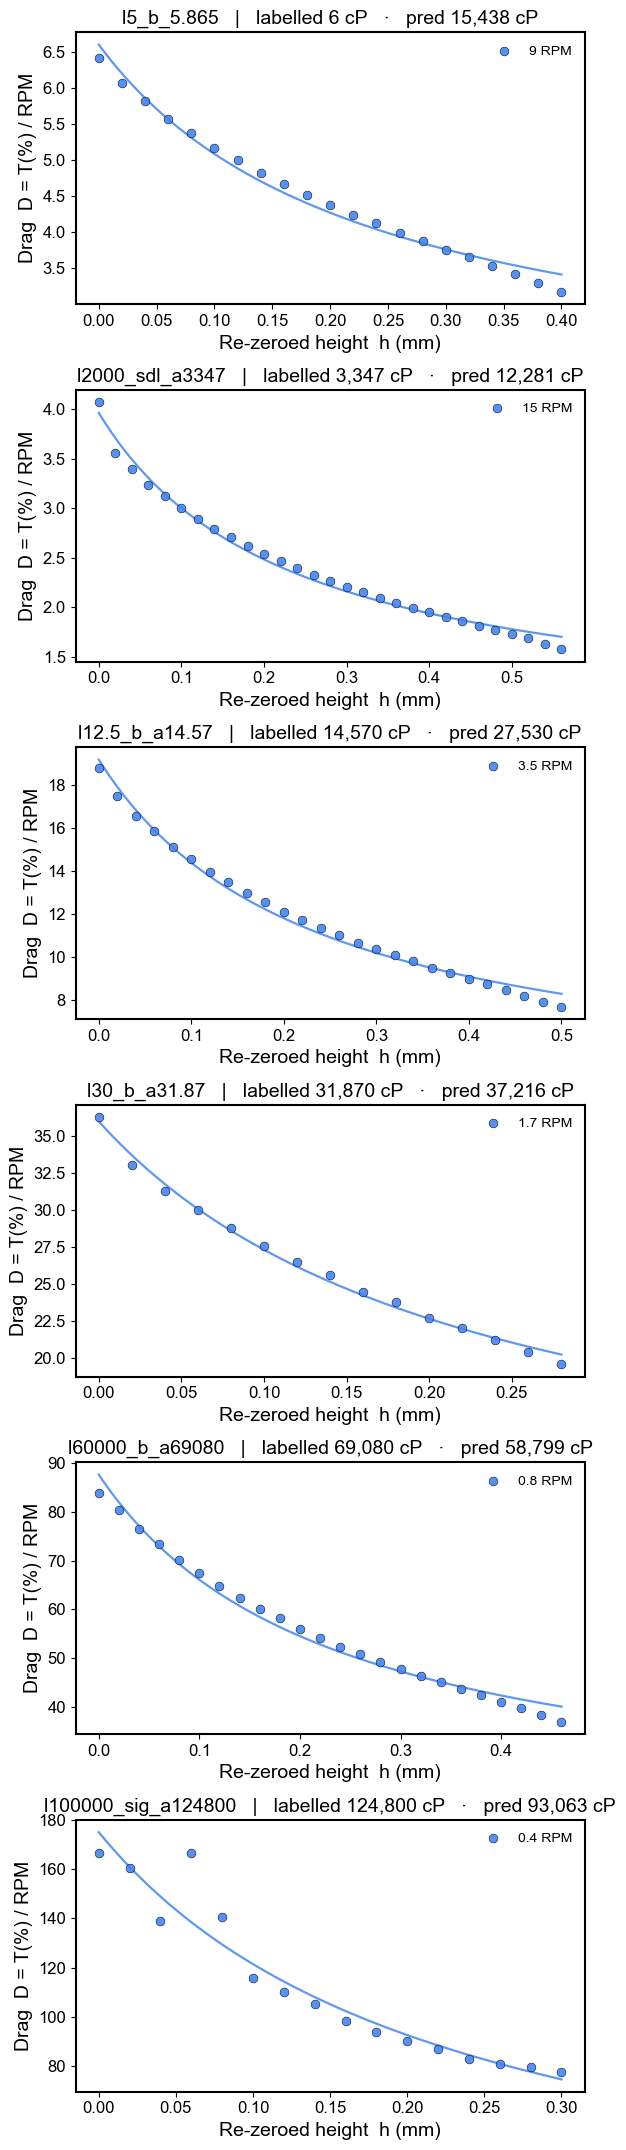

              label  true_mu_cP  n_rpms    regime  n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
l100000_sig_a124800    1.25e+05       1 Newtonian      1   9.31e+04         0.924          NaN
   l10000_sl_a11860    1.19e+04       1 Newtonian      1   1.83e+04         0.383          NaN
      l1000_b_a1000       1e+03       1 Newtonian      1   8.11e+03         0.996          NaN
     l1000_sl_a1154    1.15e+03       1 Newtonian      1   8.15e+03         0.994          NaN
     l10_sdl_a9.194    9.19e+03       1 Newtonian      1   2.09e+04          0.99          NaN
     l10_sil_a11.86    1.19e+04       1 Newtonian      1   2.18e+04         0.986          NaN
     l12.5_b_a14.57    1.46e+04       1 Newtonian      1   2.75e+04         0.991          NaN
     l12500_b_14590    1.46e+04       1 Newtonian      1   2.71e+04         0.994          NaN
  l15000_sdl_a19000     1.9e+04       1 Newtonian      1   3.17e+04         0.992          NaN
        l15_sdl_a19          19       1 Newtonian 

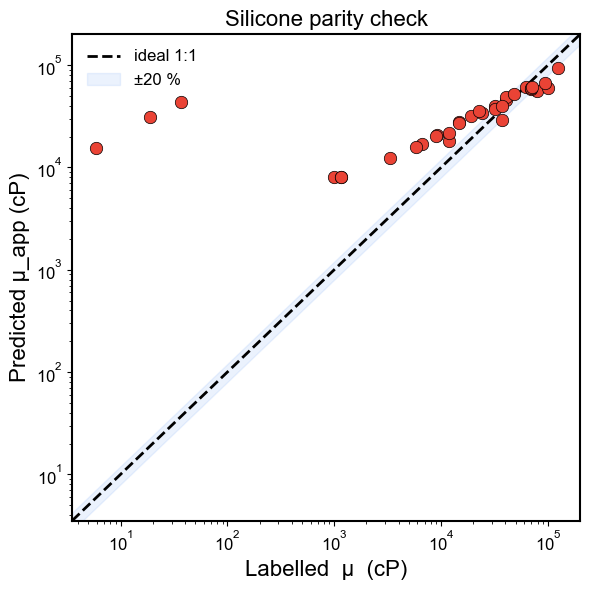

  median |error| = 54.3 %   within ±20% : 27 %   N = 33


In [43]:
# silicone has 37 cells → plot only a handful of representative ones,
# but still tabulate the full set.
summary_silicone = analyse_sample("silicone", SAMPLES["silicone"], pipeline, max_cells_to_plot=6)

# ── Parity plot: predicted vs labelled viscosity ─────────────────────────────
sil = summary_silicone.dropna(subset=["true_mu_cP", "mu_app_cP"]).copy()
sil = sil[(sil["true_mu_cP"] > 0) & (sil["mu_app_cP"] > 0)]

if not sil.empty:
    fig, ax = plt.subplots(figsize=(6, 6))
    lim = [sil["true_mu_cP"].min() * 0.6, sil["true_mu_cP"].max() * 1.6]
    ax.plot(lim, lim, "k--", lw=2, label="ideal 1:1")
    ax.fill_between(lim, [v*0.8 for v in lim], [v*1.2 for v in lim],
                    alpha=0.10, color=GOOGLE_COLORS[0], label="±20 %")
    ax.scatter(sil["true_mu_cP"], sil["mu_app_cP"],
               s=80, color=GOOGLE_COLORS[1], edgecolors="k",
               linewidths=0.5, zorder=3)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lim);     ax.set_ylim(lim)
    ax.set_xlabel("Labelled  μ  (cP)",  fontsize=FS_LABEL)
    ax.set_ylabel("Predicted μ_app (cP)", fontsize=FS_LABEL)
    ax.set_title("Silicone parity check", fontsize=FS_LABEL)
    ax.legend(fontsize=FS_LEGEND, frameon=False)
    _gs(ax)
    plt.tight_layout(); plt.show()

    err = (sil["mu_app_cP"] - sil["true_mu_cP"]) / sil["true_mu_cP"] * 100
    print(f"  median |error| = {err.abs().median():.1f} %"
          f"   within ±20% : {(err.abs() <= 20).mean()*100:.0f} %"
          f"   N = {len(sil)}")

## Step 5 — Sample 2 · PEG (poly-ethylene glycol)

PEG solutions are essentially Newtonian at low concentrations and develop mild shear-thinning at higher MW/concentration. Every PEG cell was probed at **multiple RPMs**, so the pipeline now fits a power-law $A(\dot\gamma)=A_0\,\dot\gamma^{n-1}$ and classifies each formulation.

=== PEG  —  5 cell(s)  ·  1439 rows ===


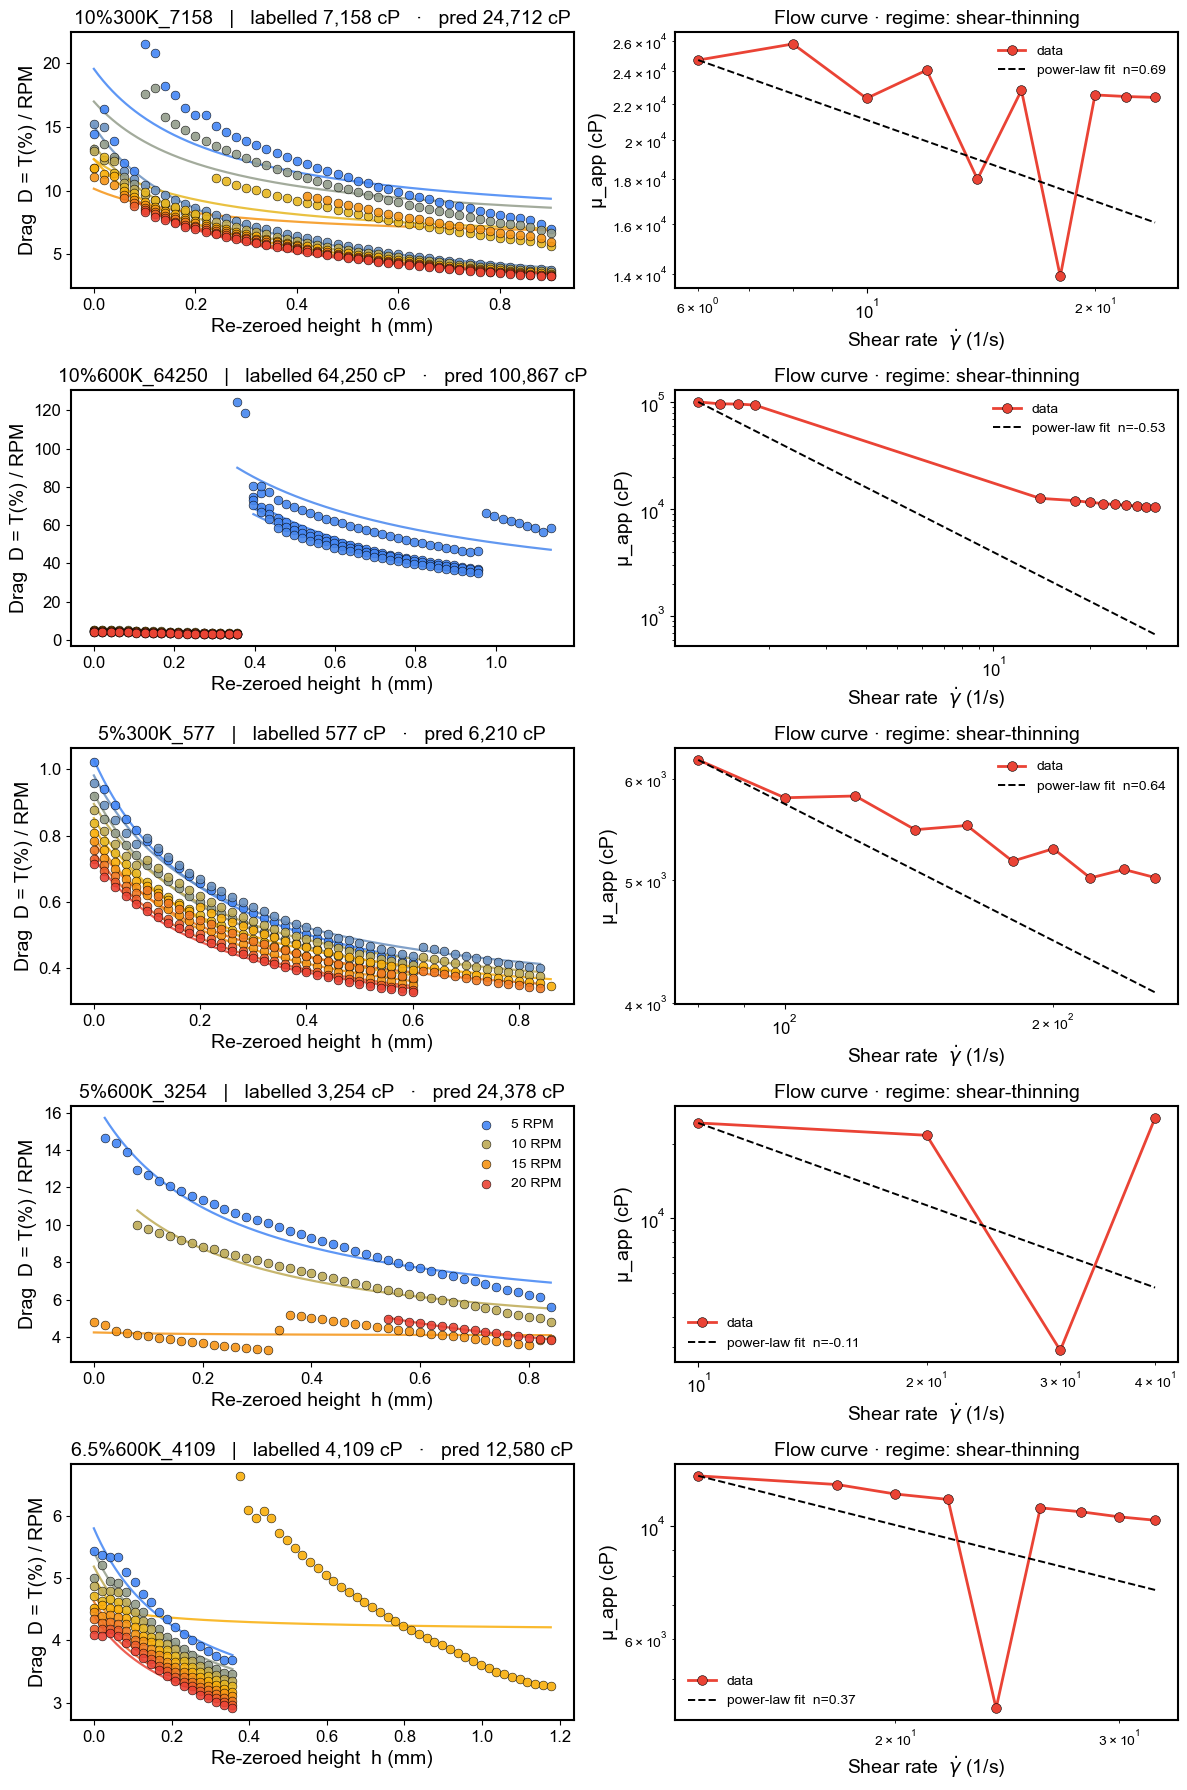

        label  true_mu_cP  n_rpms         regime  n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
 10%300K_7158    7.16e+03      10 shear-thinning  0.689   2.47e+04         0.812        0.155
10%600K_64250    6.42e+04      13 shear-thinning -0.526   1.01e+05         0.916        0.985
   5%300K_577         577      10 shear-thinning  0.643   6.21e+03         0.992         0.94
  5%600K_3254    3.25e+03       4 shear-thinning -0.108   2.44e+04         0.724        0.102
6.5%600K_4109    4.11e+03       9 shear-thinning  0.373   1.26e+04          0.83       0.0684


In [44]:
summary_PEG = analyse_sample("PEG", SAMPLES["PEG"], pipeline)

## Step 6 — Sample 3 · Sepineo (cross-linked acrylate gel)

Sepineo is a classic shear-thinning thickener used in skincare. Expect $n < 1$ and $\mu_\text{app}$ that decreases with shear rate.

=== sepineo  —  3 cell(s)  ·  847 rows ===


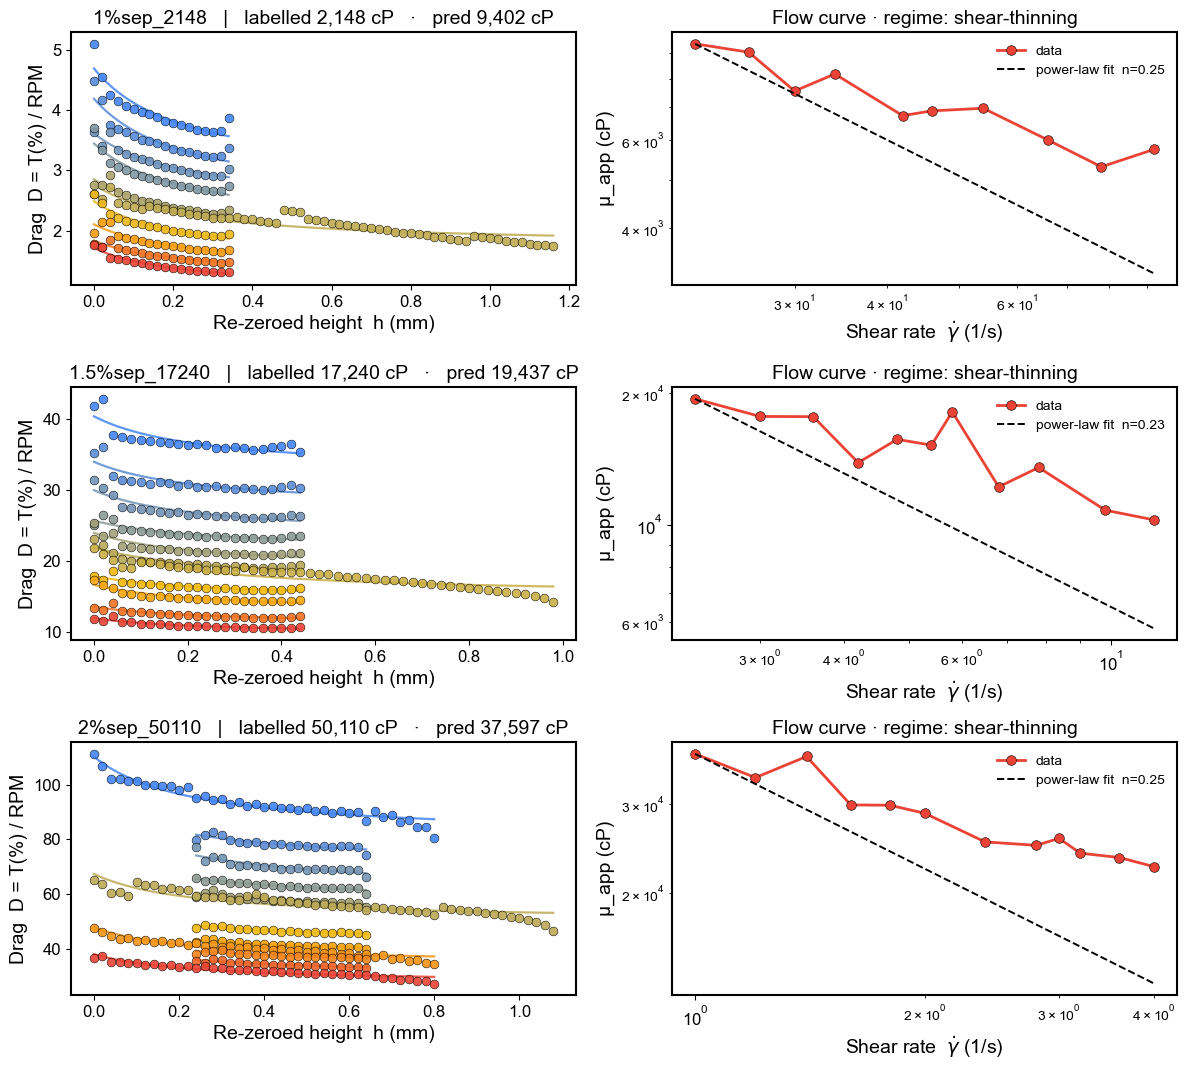

        label  true_mu_cP  n_rpms         regime  n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
   1%sep_2148    2.15e+03      10 shear-thinning  0.254    9.4e+03         0.893        0.906
1.5%sep_17240    1.72e+04      11 shear-thinning  0.232   1.94e+04         0.802        0.768
  2%sep_50110    5.01e+04      12 shear-thinning  0.248   3.76e+04         0.849        0.929


In [45]:
summary_sepineo = analyse_sample("sepineo", SAMPLES["sepineo"], pipeline)

## Step 7 — Sample 4 · Solagum (polysaccharide gum)

Solagum gels strongly with concentration; expect a steep drop of $\mu_\text{app}$ versus $\dot\gamma$ ($n \ll 1$).

=== solagum  —  3 cell(s)  ·  898 rows ===


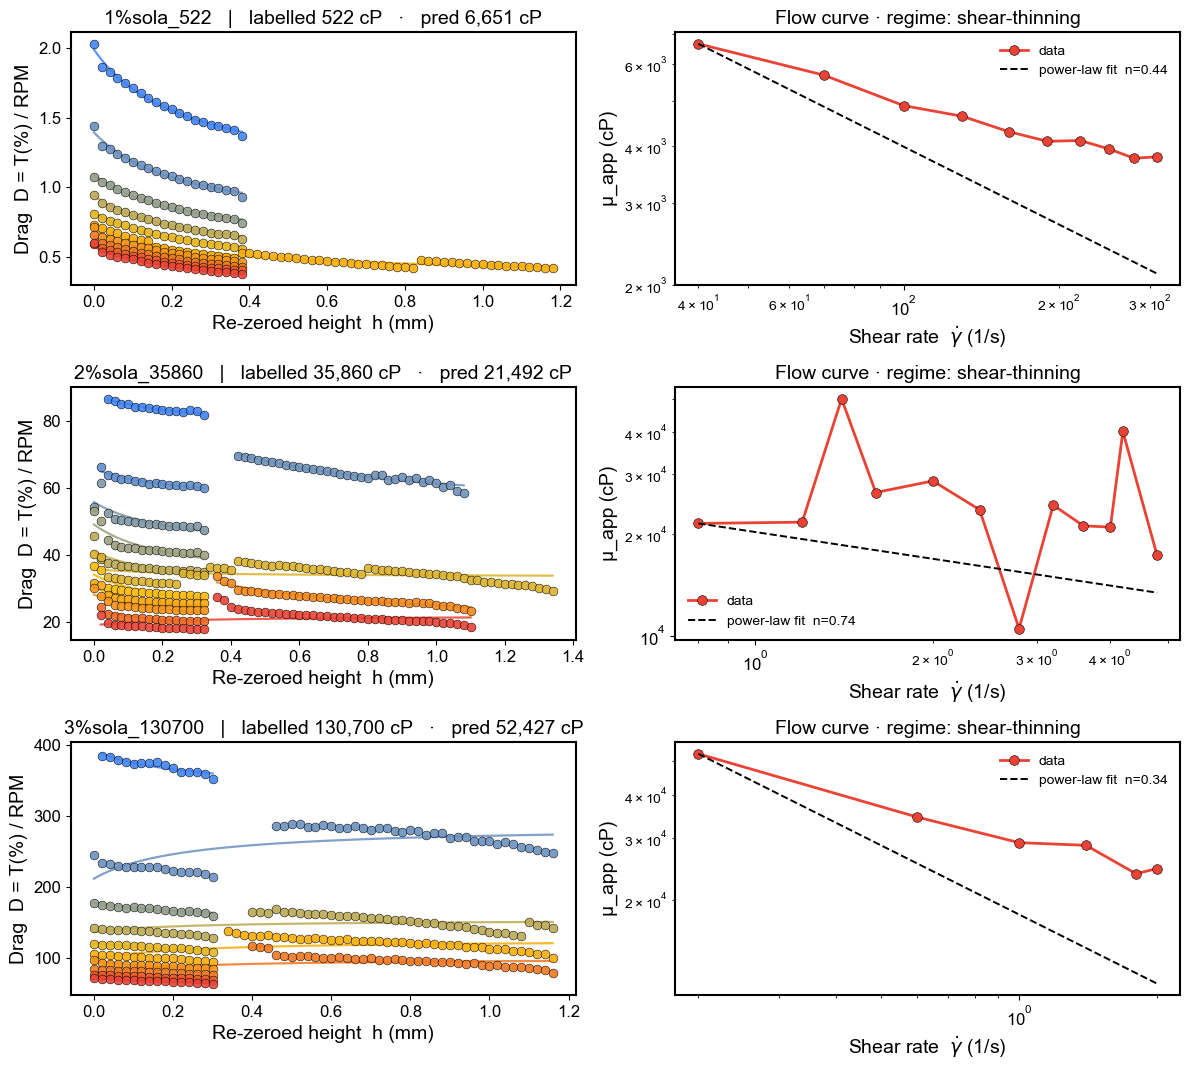

        label  true_mu_cP  n_rpms         regime  n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
   1%sola_522         522      10 shear-thinning   0.44   6.65e+03         0.986        0.984
 2%sola_35860    3.59e+04      13 shear-thinning  0.737   2.15e+04         0.704       0.0362
3%sola_130700    1.31e+05      10 shear-thinning  0.341   5.24e+04         0.635        0.979


In [46]:
summary_solagum = analyse_sample("solagum", SAMPLES["solagum"], pipeline)

## Step 8 — Sample 5 · Carbopol 980 (yield-pseudoplastic)

Carbopol exhibits a yield stress plus strong shear-thinning. The power-law fit captures the high-shear branch ($n \ll 1$); the yield contribution shows up as the up-turn of $\mu_\text{app}$ at the lowest shear rates.

=== carbopol  —  2 cell(s)  ·  296 rows ===


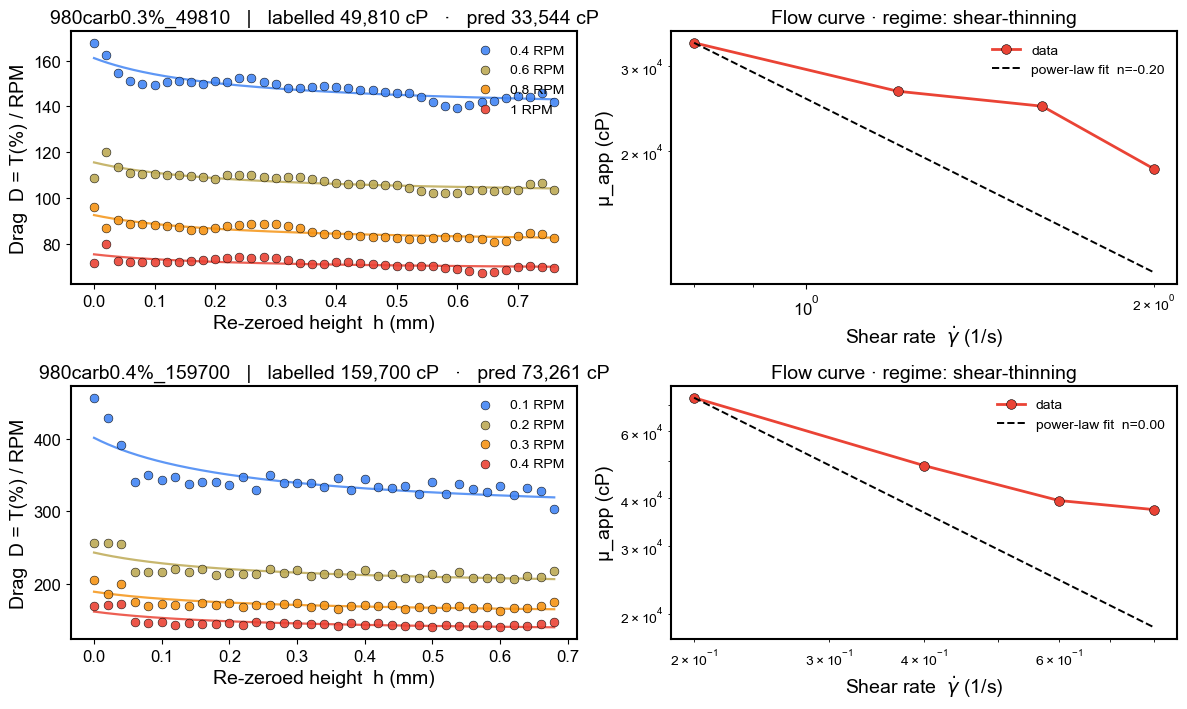

             label  true_mu_cP  n_rpms         regime   n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
 980carb0.3%_49810    4.98e+04       4 shear-thinning    -0.2   3.35e+04         0.646        0.922
980carb0.4%_159700     1.6e+05       4 shear-thinning 0.00449   7.33e+04         0.602        0.979


In [47]:
summary_carbopol = analyse_sample("carbopol", SAMPLES["carbopol"], pipeline)

## Step 9 — Cross-sample summary

A single tidy table of every cell across all five materials, followed by a master flow-curve plot that overlays one representative cell per non-Newtonian sample so the rheology fingerprints can be compared at a glance.

Total cells analysed: 47

  sample               label  true_mu_cP  n_rpms         regime   n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
silicone l100000_sig_a124800    1.25e+05       1      Newtonian       1   9.31e+04         0.924          NaN
silicone    l10000_sl_a11860    1.19e+04       1      Newtonian       1   1.83e+04         0.383          NaN
silicone       l1000_b_a1000       1e+03       1      Newtonian       1   8.11e+03         0.996          NaN
silicone      l1000_sl_a1154    1.15e+03       1      Newtonian       1   8.15e+03         0.994          NaN
silicone      l10_sdl_a9.194    9.19e+03       1      Newtonian       1   2.09e+04          0.99          NaN
silicone      l10_sil_a11.86    1.19e+04       1      Newtonian       1   2.18e+04         0.986          NaN
silicone      l12.5_b_a14.57    1.46e+04       1      Newtonian       1   2.75e+04         0.991          NaN
silicone      l12500_b_14590    1.46e+04       1      Newtonian       1   2.71e+04         0.9

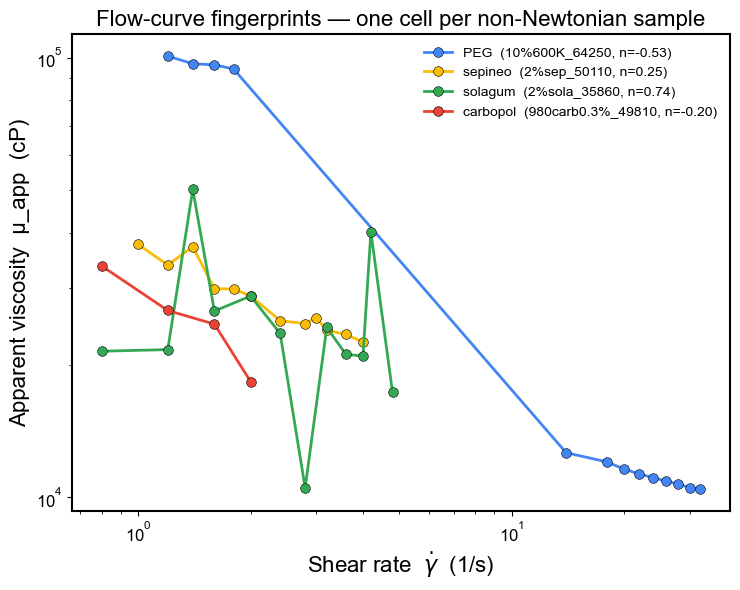


Summary written → Rheology_Newtonian_Non_Newtonian_Material\rheology_pipeline_summary.csv


In [48]:
summary_all = pd.concat(
    [summary_silicone, summary_PEG, summary_sepineo, summary_solagum, summary_carbopol],
    ignore_index=True,
)

print(f"Total cells analysed: {len(summary_all)}")
print()

with pd.option_context("display.float_format", "{:,.3g}".format,
                       "display.max_rows", 200,
                       "display.width", 140):
    cols = ["sample", "label", "true_mu_cP", "n_rpms",
            "regime", "n_idx", "mu_app_cP", "R2_drag_mean", "R2_powerlaw"]
    print(summary_all[cols].to_string(index=False))

# ── Master flow-curve comparison: one representative cell per non-Newtonian sample
def _pick_cell(df_all, sample):
    sub = df_all[df_all["Cell_Label"].isin(
        summary_all.loc[summary_all["sample"] == sample, "label"]
    )]
    # representative = cell with the most RPM points
    counts = (sub.groupby("Cell_Label")["RPM"].nunique()
              .sort_values(ascending=False))
    return counts.index[0] if len(counts) else None

fig, ax = plt.subplots(figsize=(7.5, 6))
colors = {"PEG"     : GOOGLE_COLORS[0],
          "sepineo" : GOOGLE_COLORS[2],
          "solagum" : GOOGLE_COLORS[3],
          "carbopol": GOOGLE_COLORS[1]}

for sample in ["PEG", "sepineo", "solagum", "carbopol"]:
    df = load_sample(SAMPLES[sample])
    cl = _pick_cell(df, sample)
    if cl is None:
        continue
    an = analyse_cell(df[df["Cell_Label"] == cl], pipeline)
    pr = an["per_rpm"].dropna(subset=["mu_app_cP"])
    pr = pr[pr["mu_app_cP"] > 0]
    if pr.empty:
        continue
    label_txt = f"{sample}  ({cl}, n={an['result'].get('n', float('nan')):.2f})"
    ax.plot(pr["gamma_dot_1_s"], pr["mu_app_cP"],
            "-o", color=colors[sample], lw=2.0, ms=7,
            markeredgecolor="k", markeredgewidth=0.4, label=label_txt)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Shear rate  $\dot\gamma$  (1/s)", fontsize=FS_LABEL)
ax.set_ylabel("Apparent viscosity  μ_app  (cP)",   fontsize=FS_LABEL)
ax.set_title("Flow-curve fingerprints — one cell per non-Newtonian sample", fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND - 2, frameon=False, loc="best")
_gs(ax)
plt.tight_layout(); plt.show()

# ── Save the unified summary CSV next to the data ────────────────────────────
out_csv = DATA_DIR / "rheology_pipeline_summary.csv"
summary_all.to_csv(out_csv, index=False)
print(f"\nSummary written → {out_csv.relative_to(REPO)}")

## Step 10 — Shear stress vs shear rate (all samples)

Convert the per-RPM apparent viscosity to shear stress via

$$\tau\,[\text{Pa}] = \mu_\text{app}\,[\text{Pa·s}]\;\dot\gamma\,[\text{1/s}] = \frac{\mu_\text{app}\,[\text{cP}]}{1000}\;\dot\gamma\,[\text{1/s}],$$

and plot $\tau(\dot\gamma)$ on log–log axes for every cell of every sample, one subplot per sample.


Built shear-stress table: 149 (cell, RPM) points across 5 samples

--- Power-law fits (after outlier cleaning) ---
  PEG      PEG-300K  5%            K=    13.5  n= 0.82  R²= 1.00  kept 10/10
  PEG      PEG-300K  10%           K=    33.5  n= 0.87  R²= 1.00  kept 6/10
  PEG      PEG-600K  5%            K=    21.5  n= 1.03  R²= 0.99  kept 3/4
  PEG      PEG-600K  6.5%          K=      24  n= 0.76  R²= 1.00  kept 7/9
  PEG      PEG-600K  10%           K=     124  n= 0.24  R²= 0.85  kept 12/13
  sepineo  Sepineo  1%             K=    28.1  n= 0.63  R²= 0.95  kept 8/10
  sepineo  Sepineo  1.5%           K=    27.8  n= 0.60  R²= 0.95  kept 10/11
  sepineo  Sepineo  2%             K=    36.3  n= 0.65  R²= 0.99  kept 7/12
  solagum  Solagum  1%             K=    18.5  n= 0.72  R²= 1.00  kept 10/10
  solagum  Solagum  2%             K=    24.3  n= 0.91  R²= 0.94  kept 9/12
  solagum  Solagum  3%             K=    30.3  n= 0.67  R²= 1.00  kept 5/6
  carbopol Carbopol 980  0.3%      K=    29.9  n

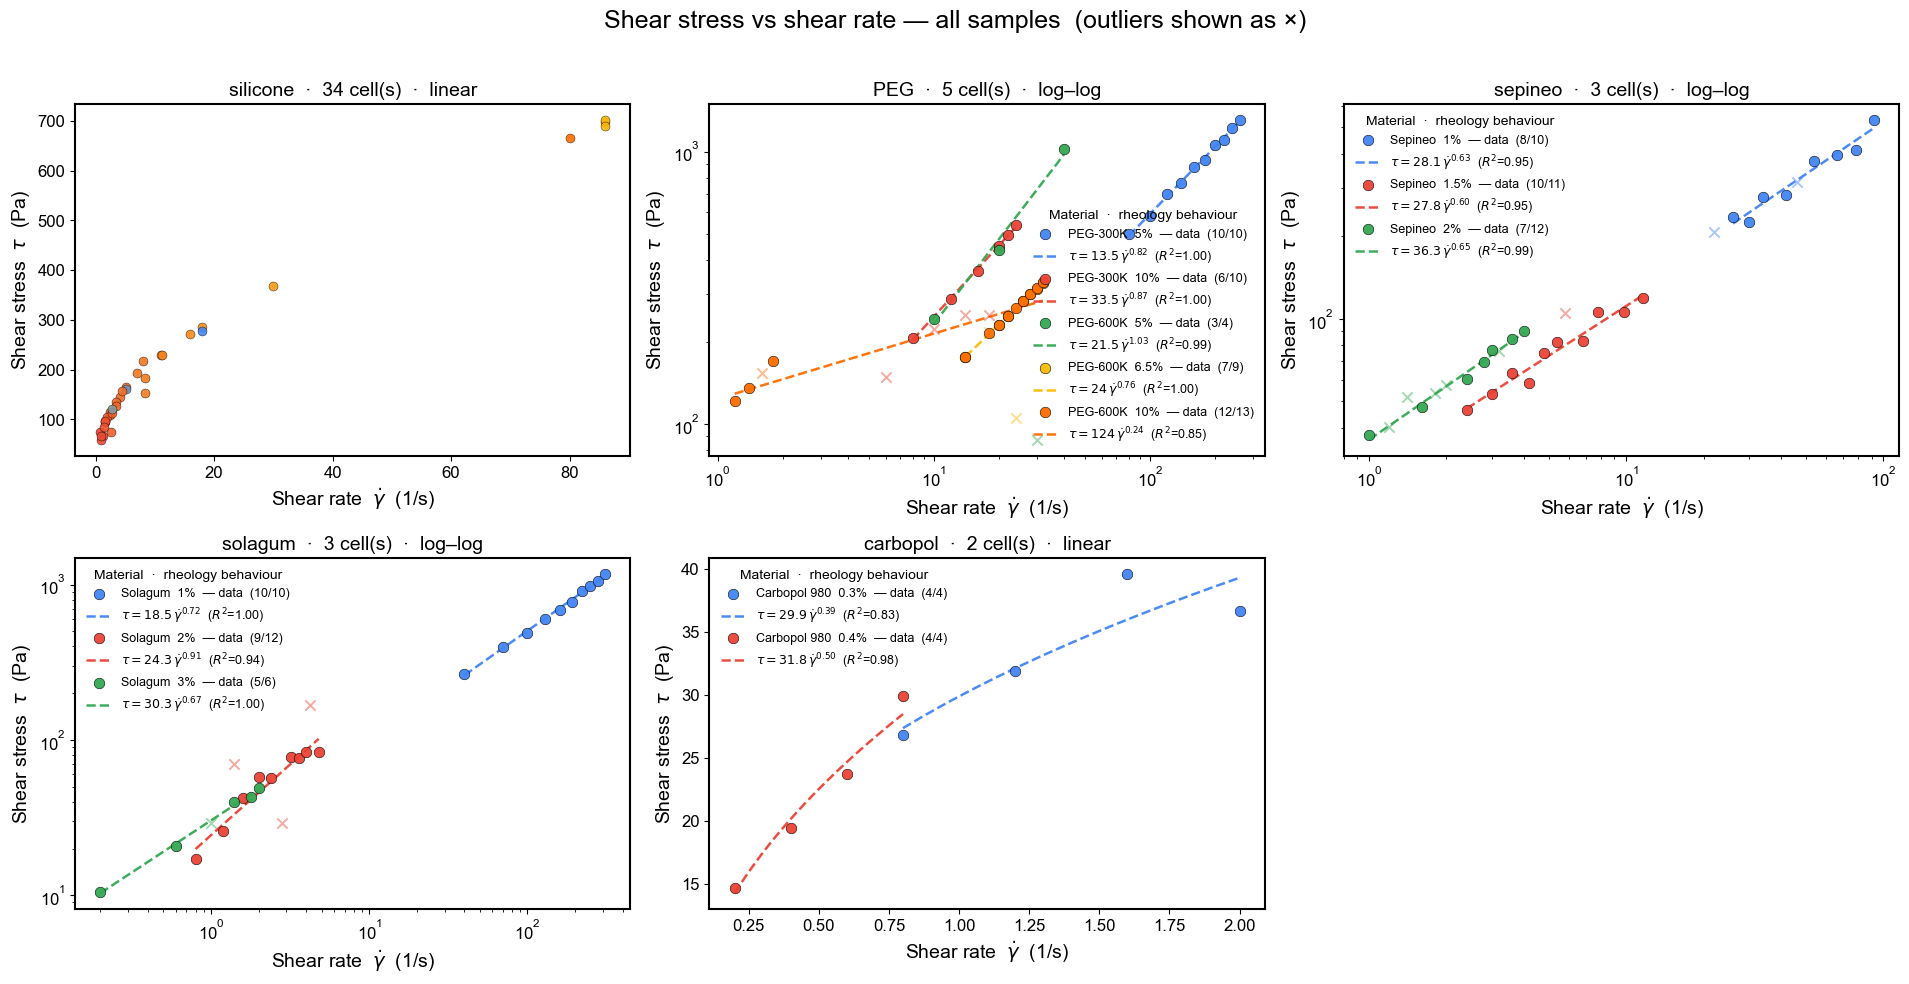

In [49]:
# ── Build a tidy (sample, cell, RPM) table of shear stress vs shear rate ────
# Keep the per-RPM drag-fit R² (`R2drag`) so we can reject bad RPMs later.
stress_rows = []
for sample, path in SAMPLES.items():
    df = load_sample(path)
    for cl in df["Cell_Label"].dropna().unique():
        an = analyse_cell(df[df["Cell_Label"] == cl], pipeline)
        pr = an["per_rpm"].dropna(subset=["mu_app_cP", "gamma_dot_1_s"]).copy()
        pr = pr[(pr["mu_app_cP"] > 0) & (pr["gamma_dot_1_s"] > 0)]
        if pr.empty:
            continue
        pr["sample"]     = sample
        pr["label"]      = cl
        pr["tau_Pa"]     = (pr["mu_app_cP"] / 1000.0) * pr["gamma_dot_1_s"]
        pr["true_mu_cP"] = parse_true_mu(cl)
        pr["R2drag"]     = pr["R2"]
        stress_rows.append(pr[["sample", "label", "true_mu_cP",
                               "RPM", "gamma_dot_1_s", "mu_app_cP",
                               "tau_Pa", "R2drag"]])

stress_df = pd.concat(stress_rows, ignore_index=True)
print(f"Built shear-stress table: {len(stress_df)} (cell, RPM) points "
      f"across {stress_df['sample'].nunique()} samples")


# ── Pretty material names parsed from the cell labels ───────────────────────
_RE_PEG       = re.compile(r"(?P<conc>\d+(?:\.\d+)?)%(?P<mw>\d+)K", re.I)
_RE_PCT_NAME  = re.compile(r"(?P<conc>\d+(?:\.\d+)?)%(?P<name>[A-Za-z]+)", re.I)
_RE_CARBOPOL  = re.compile(r"(?P<grade>\d+)carb(?P<conc>\d+(?:\.\d+)?)%", re.I)

def material_name(sample: str, cl: str) -> str:
    """Turn a raw Cell_Label into a human-readable material name."""
    s = str(cl)
    m = _RE_CARBOPOL.search(s)
    if m:
        return f"Carbopol {m.group('grade')}  {float(m.group('conc')):g}%"
    m = _RE_PEG.search(s)
    if m:
        return f"PEG-{m.group('mw')}K  {float(m.group('conc')):g}%"
    m = _RE_PCT_NAME.search(s)
    if m:
        nm = m.group("name").lower()
        pretty = {"sep": "Sepineo", "sola": "Solagum"}.get(nm, nm.capitalize())
        return f"{pretty}  {float(m.group('conc')):g}%"
    return s


# ── Power-law fit  τ = K · γ̇^n  (linear in log–log) ────────────────────────
def fit_power_law(gamma_dot: np.ndarray, tau: np.ndarray):
    """Return (K, n, R2) for τ = K γ̇^n; NaNs if it cannot be fitted."""
    g = np.asarray(gamma_dot, float)
    t = np.asarray(tau, float)
    m = np.isfinite(g) & np.isfinite(t) & (g > 0) & (t > 0)
    if m.sum() < 2:
        return float("nan"), float("nan"), float("nan")
    lg, lt = np.log(g[m]), np.log(t[m])
    n, logK = np.polyfit(lg, lt, 1)
    K = float(np.exp(logK))
    ss_res = float(np.sum((lt - (logK + n * lg)) ** 2))
    ss_tot = float(np.sum((lt - lt.mean()) ** 2))
    R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return K, float(n), R2


# ── Outlier cleaner ────────────────────────────────────────────────────────
def clean_for_powerlaw(d: pd.DataFrame,
                       r2_drag_min: float = 0.85,
                       mad_k: float = 2.5,
                       min_keep: int = 3,
                       max_iter: int = 6) -> np.ndarray:
    """
    Boolean mask (aligned with `d`) of (γ̇, τ) points to KEEP for the
    power-law fit.

    Strategy:
      1. Pre-filter on drag-fit quality (R² ≥ `r2_drag_min`):
         - On small datasets (≤5 pts) apply whenever ≥min_keep remain
           (small datasets cannot tolerate any single bad point).
         - On larger datasets require ≥50% retention to avoid over-pruning
           when most per-RPM fits are mediocre (e.g. very viscous gels).
      2. Iteratively reject the worst residual in log–log space while
         |residual| > mad_k × 1.4826 × MAD, never falling below `min_keep`.
    """
    base = (np.isfinite(d["gamma_dot_1_s"]) & np.isfinite(d["tau_Pa"]) &
            (d["gamma_dot_1_s"] > 0) & (d["tau_Pa"] > 0)).to_numpy()
    keep = base.copy()

    # (1) Quality pre-filter on the per-RPM drag fits.
    if "R2drag" in d:
        q_keep = base & (d["R2drag"].to_numpy() >= r2_drag_min)
        n_base = int(base.sum())
        min_required = (min_keep if n_base <= 5
                        else max(min_keep + 1, int(0.5 * n_base)))
        if q_keep.sum() >= min_required:
            keep = q_keep

    if keep.sum() < min_keep:
        keep = base.copy()

    # (2) Iterative MAD-based rejection in log–log τ–γ̇ space.
    lg = np.log(d["gamma_dot_1_s"].to_numpy())
    lt = np.log(d["tau_Pa"].to_numpy())
    for _ in range(max_iter):
        idx = np.where(keep)[0]
        if len(idx) <= min_keep:
            break
        n, logK = np.polyfit(lg[idx], lt[idx], 1)
        res = lt[idx] - (logK + n * lg[idx])
        mad = np.median(np.abs(res - np.median(res))) or 1e-12
        worst = int(np.argmax(np.abs(res)))
        if abs(res[worst]) <= mad_k * 1.4826 * mad:
            break
        keep[idx[worst]] = False

    return keep


# ── Which cells to plot per sample (subset requested by the user) ───────────
SAMPLE_CELLS = {
    "silicone": None,  # plot all silicone cells, no legend
    "PEG":      ["5%300K_577",   "10%300K_7158",
                 "5%600K_3254",  "6.5%600K_4109", "10%600K_64250"],
    "sepineo":  ["1%sep_2148",   "1.5%sep_17240", "2%sep_50110"],
    "solagum":  ["1%sola_522",   "2%sola_35860",  "3%sola_130700"],
    "carbopol": ["980carb0.3%_49810", "980carb0.4%_159700"],
}

# Subplots that should use linear axes (everything else stays log–log).
LINEAR_SAMPLES = {"silicone", "carbopol"}

# Colours per cell within a sample (one distinct colour per concentration).
PALETTE = ["#4285F4", "#EA4335", "#34A853", "#FBBC05", "#FF6D00", "#46BDC6"]


# ── Plot τ vs γ̇ — one subplot per sample ──────────────────────────────────
samples_order = ["silicone", "PEG", "sepineo", "solagum", "carbopol"]
ncols = 3
nrows = int(np.ceil(len(samples_order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.4 * ncols, 4.8 * nrows), squeeze=False)

print("\n--- Power-law fits (after outlier cleaning) ---")
for idx, sample in enumerate(samples_order):
    ax = axes[idx // ncols, idx % ncols]
    sub = stress_df[stress_df["sample"] == sample]
    if sub.empty:
        ax.set_visible(False)
        continue

    wanted = SAMPLE_CELLS[sample]
    if wanted is None:
        cells = list(sub["label"].unique())
    else:
        present = set(sub["label"].unique())
        cells = [c for c in wanted if c in present]
        missing = [c for c in wanted if c not in present]
        if missing:
            print(f"  [warn] {sample}: missing requested cells → {missing}")

    if sample == "silicone":
        # ── Silicone: scatter only, no legend ────────────────────────────────
        mus = (sub.groupby("label")["true_mu_cP"].first().reindex(cells).to_numpy())
        finite_mu = np.isfinite(mus) & (mus > 0)
        if finite_mu.sum() >= 2:
            vmin, vmax = np.nanmin(mus[finite_mu]), np.nanmax(mus[finite_mu])
            norm = mpl.colors.LogNorm(vmin=max(vmin, 1e-3),
                                      vmax=max(vmax, vmin * 1.01))
            colors = [GOOGLE_CMAP(norm(mu)) if (np.isfinite(mu) and mu > 0)
                      else GOOGLE_COLORS[i % len(GOOGLE_COLORS)]
                      for i, mu in enumerate(mus)]
        else:
            colors = [GOOGLE_COLORS[i % len(GOOGLE_COLORS)]
                      for i in range(len(cells))]
        for cl, c in zip(cells, colors):
            d = sub[sub["label"] == cl]
            ax.scatter(d["gamma_dot_1_s"], d["tau_Pa"],
                       s=42, color=c, edgecolors="k", linewidths=0.3,
                       alpha=0.9, zorder=3)
    else:
        # ── Non-Newtonian samples: clean, fit, plot ────────────────────────
        for i, cl in enumerate(cells):
            d = (sub[sub["label"] == cl]
                 .sort_values("gamma_dot_1_s")
                 .reset_index(drop=True))
            c   = PALETTE[i % len(PALETTE)]
            mat = material_name(sample, cl)

            keep = clean_for_powerlaw(d)
            n_total, n_keep = len(d), int(keep.sum())
            d_in, d_out = d[keep], d[~keep]

            # Accepted points (used in the fit)
            ax.scatter(d_in["gamma_dot_1_s"], d_in["tau_Pa"],
                       s=58, color=c, edgecolors="k", linewidths=0.4,
                       alpha=0.95, zorder=4,
                       label=f"{mat}  — data  ({n_keep}/{n_total})")

            # Rejected points (shown but greyed out)
            if not d_out.empty:
                ax.scatter(d_out["gamma_dot_1_s"], d_out["tau_Pa"],
                           s=55, marker="x", color=c, alpha=0.45,
                           linewidths=1.4, zorder=3)

            # Power-law fit through the accepted points only
            K, n, R2 = fit_power_law(d_in["gamma_dot_1_s"].to_numpy(),
                                     d_in["tau_Pa"].to_numpy())
            if np.isfinite(K) and np.isfinite(n):
                gmin = float(d_in["gamma_dot_1_s"].min())
                gmax = float(d_in["gamma_dot_1_s"].max())
                gg = np.geomspace(gmin, gmax, 100)
                ax.plot(gg, K * gg ** n, "--", color=c, lw=1.8, alpha=0.95,
                        label=(rf"$\tau = {K:.3g}\,\dot\gamma^{{{n:.2f}}}$"
                               rf"  ($R^2$={R2:.2f})"))
                print(f"  {sample:<8s} {mat:<22s}  "
                      f"K={K:8.3g}  n={n:5.2f}  R²={R2:5.2f}  "
                      f"kept {n_keep}/{n_total}")

    # Axis scale: linear for silicone & carbopol, log–log for the rest.
    if sample not in LINEAR_SAMPLES:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_xlabel(r"Shear rate  $\dot\gamma$  (1/s)", fontsize=FS_LABEL - 2)
    ax.set_ylabel(r"Shear stress  $\tau$  (Pa)",       fontsize=FS_LABEL - 2)
    scale_tag = "linear" if sample in LINEAR_SAMPLES else "log–log"
    ax.set_title(f"{sample}  ·  {len(cells)} cell(s)  ·  {scale_tag}",
                 fontsize=FS_LABEL - 2)
    _gs(ax)

    if sample != "silicone":
        ax.legend(fontsize=FS_LEGEND - 3, frameon=False, loc="best",
                  title="Material  ·  rheology behaviour",
                  title_fontsize=FS_LEGEND - 2)

# Hide any unused axes
for j in range(len(samples_order), nrows * ncols):
    axes[j // ncols, j % ncols].set_visible(False)

fig.suptitle("Shear stress vs shear rate — all samples  (outliers shown as ×)",
             fontsize=FS_LABEL + 2, y=1.02)
plt.tight_layout()
plt.show()
